In [42]:
import pandas as pd
import plotly.express as px
import calendar
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from dash import Dash, dcc, html, Input, Output, State, callback_context
import plotly.io as pio

# Save also static images of the plots
pio.renderers.default = "notebook_connected+png"

# Data preprocessing 

In [43]:
df = pd.read_csv('Airline_Delay_Cause.csv')

In [44]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [45]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

Number of rows: 171666
Number of columns: 21


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  str    
 3   carrier_name         171666 non-null  str    
 4   airport              171666 non-null  str    
 5   airport_name         171666 non-null  str    
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay            171426 

There aren't null values.

In [47]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [48]:
df.describe(include = ['O'])

C:\Users\mirco\AppData\Local\Temp\ipykernel_22220\634265764.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = ['O'])


,carrier,carrier_name,airport,airport_name
count,171666,171666,171666,171666
unique,21,23,395,419
top,OO,SkyWest Airlines Inc.,DTW,"Detroit, MI: Detroit Metro Wayne County"
freq,25593,25593,1535,1535


We can note that the airports and carriers name are more than the codes, maybe some names are changed.

In [49]:
# delete rows with NaN values
df_filtered = df.dropna()

# check for NaN values in the filtered dataframe
nan_values = df_filtered.isna().sum()
print('Number of NaN values in the filtered dataframe:')
print(nan_values)

Number of NaN values in the filtered dataframe:
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64


## Filter the data to have only the top 50 airports

At first we can filter the airport and take only top 50 for flights volume.

In [50]:
# filter the data to only include top 50 airports with the highest number of flights
top_50_airports = df_filtered.groupby('airport')['arr_flights'].sum().nlargest(50).index.to_list()
top_50_airports

['ATL',
 'ORD',
 'DFW',
 'DEN',
 'LAX',
 'CLT',
 'PHX',
 'LAS',
 'SFO',
 'IAH',
 'SEA',
 'DTW',
 'MCO',
 'MSP',
 'LGA',
 'BOS',
 'EWR',
 'SLC',
 'JFK',
 'DCA',
 'BWI',
 'PHL',
 'FLL',
 'MIA',
 'MDW',
 'SAN',
 'TPA',
 'BNA',
 'DAL',
 'AUS',
 'STL',
 'PDX',
 'HOU',
 'IAD',
 'HNL',
 'SJC',
 'RDU',
 'OAK',
 'MSY',
 'MCI',
 'SMF',
 'SNA',
 'CLE',
 'IND',
 'PIT',
 'SAT',
 'CMH',
 'RSW',
 'CVG',
 'MKE']

In [51]:
# filter the df in order to take only the top 50 airports
df_top = df_filtered[df_filtered['airport'].isin(top_50_airports)].copy()

In [52]:
df_top.info()

<class 'pandas.DataFrame'>
Index: 62309 entries, 5 to 171663
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 62309 non-null  int64  
 1   month                62309 non-null  int64  
 2   carrier              62309 non-null  str    
 3   carrier_name         62309 non-null  str    
 4   airport              62309 non-null  str    
 5   airport_name         62309 non-null  str    
 6   arr_flights          62309 non-null  float64
 7   arr_del15            62309 non-null  float64
 8   carrier_ct           62309 non-null  float64
 9   weather_ct           62309 non-null  float64
 10  nas_ct               62309 non-null  float64
 11  security_ct          62309 non-null  float64
 12  late_aircraft_ct     62309 non-null  float64
 13  arr_cancelled        62309 non-null  float64
 14  arr_diverted         62309 non-null  float64
 15  arr_delay            62309 non-null  float64
 16  c

In [53]:
df_top.describe(include = ['O'])

C:\Users\mirco\AppData\Local\Temp\ipykernel_22220\3411455453.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_top.describe(include = ['O'])


,carrier,carrier_name,airport,airport_name
count,62309,62309,62309,62309
unique,21,23,50,52
top,DL,Delta Air Lines Inc.,DTW,"Detroit, MI: Detroit Metro Wayne County"
freq,6021,6021,1535,1535


Now we have only the flights of the top 50 airports

Now let's check the duplicate carrier name and correct them:

In [54]:
pairs = df_top[["carrier", "carrier_name"]].drop_duplicates().sort_values("carrier")
print(pairs.to_string(index=False))

carrier                 carrier_name
     9E            Endeavor Air Inc.
     AA       American Airlines Inc.
     AS         Alaska Airlines Inc.
     B6              JetBlue Airways
     DL         Delta Air Lines Inc.
     EV     ExpressJet Airlines Inc.
     EV      ExpressJet Airlines LLC
     F9       Frontier Airlines Inc.
     FL  AirTran Airways Corporation
     G4                Allegiant Air
     HA       Hawaiian Airlines Inc.
     MQ American Eagle Airlines Inc.
     MQ                    Envoy Air
     NK             Spirit Air Lines
     OH            PSA Airlines Inc.
     OO        SkyWest Airlines Inc.
     QX                  Horizon Air
     UA        United Air Lines Inc.
     US              US Airways Inc.
     VX               Virgin America
     WN       Southwest Airlines Co.
     YV           Mesa Airlines Inc.
     YX             Republic Airline


In [55]:
# names to fix
carrier_name_fix = {
    "EV": "ExpressJet Airlines Inc.",
    "MQ": "Envoy Air",
}

# map the carrier names to the fixed names, and fill all the other names with the original names
df_top["carrier_name"] = df_top["carrier"].map(carrier_name_fix).fillna(df_top["carrier_name"])

Now let's check the duplicate airport name and correct them:

In [56]:
pairs = df_top[["airport", "airport_name"]].drop_duplicates().sort_values(by="airport_name")
print(pairs.to_string(index=False))

airport                                                        airport_name
    ATL               Atlanta, GA: Hartsfield-Jackson Atlanta International
    AUS                        Austin, TX: Austin - Bergstrom International
    BWI Baltimore, MD: Baltimore/Washington International Thurgood Marshall
    BOS                                     Boston, MA: Logan International
    CLT                      Charlotte, NC: Charlotte Douglas International
    MDW                           Chicago, IL: Chicago Midway International
    ORD                           Chicago, IL: Chicago O'Hare International
    CVG          Cincinnati, OH: Cincinnati/Northern Kentucky International
    CLE                      Cleveland, OH: Cleveland-Hopkins International
    CMH                     Columbus, OH: John Glenn Columbus International
    DAL                                       Dallas, TX: Dallas Love Field
    DFW              Dallas/Fort Worth, TX: Dallas/Fort Worth International
    DEN     

In [57]:
# names to fix
airport_name_fix = {
    # duplicate airport names with different codes
    "LAS": "Las Vegas, NV: Harry Reid International",
    "OAK": "Oakland, CA: Metro Oakland International",
    # change name
    "MDW": "Chicago Midway, IL:",
    "ORD": "Chicago O'Hare, IL:",
    "IAH": "Houston Bush, TX:",
    "HOU": "Houston Hobby, TX:",
    "JFK": "New York Kennedy, NY:",
    "LGA": "New York LaGuardia, NY:",
    "DCA": "Washington Reagan, DC:",
    "IAD": "Washington Dulles, DC:",
}

# map the carrier names to the fixed names, and fill all the other names with the original names
df_top["airport_name"] = df_top["airport"].map(airport_name_fix).fillna(df_top["airport_name"])

In [58]:
# clean the airport names by removing the text after the :
df_top["airport_name"] = df_top["airport_name"].str.split(":").str[0].str.strip()

In [59]:
df_top.describe(include = ['O'])

C:\Users\mirco\AppData\Local\Temp\ipykernel_22220\3411455453.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_top.describe(include = ['O'])


,carrier,carrier_name,airport,airport_name
count,62309,62309,62309,62309
unique,21,21,50,50
top,DL,Delta Air Lines Inc.,DTW,"Detroit, MI"
freq,6021,6021,1535,1535


Check null values:

In [60]:
# check for NaN values in the filtered dataframe
nan_values = df_top.isna().sum()
nan_rows = df_top.index[df_top.isna().any(axis=1)]
print('Number of NaN values in the filtered dataframe:')
print(nan_values)
print('Rows with NaN values:')
print(nan_rows)

Number of NaN values in the filtered dataframe:
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64
Rows with NaN values:
Index([], dtype='int64')


## Merge the airport coordinates

In [61]:
df_airports_coordinates = pd.read_csv('airports.csv')

In [62]:
df_airports_coordinates.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [63]:
# filter the df_airports_coordinates to only include the columns we need
airports_filtered = df_airports_coordinates[['iata_code', 'latitude_deg', 'longitude_deg']]

df_top = df_top.merge(airports_filtered, left_on='airport', right_on='iata_code', how='left')

In [64]:
df_top.info()

<class 'pandas.DataFrame'>
RangeIndex: 62309 entries, 0 to 62308
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 62309 non-null  int64  
 1   month                62309 non-null  int64  
 2   carrier              62309 non-null  str    
 3   carrier_name         62309 non-null  str    
 4   airport              62309 non-null  str    
 5   airport_name         62309 non-null  object 
 6   arr_flights          62309 non-null  float64
 7   arr_del15            62309 non-null  float64
 8   carrier_ct           62309 non-null  float64
 9   weather_ct           62309 non-null  float64
 10  nas_ct               62309 non-null  float64
 11  security_ct          62309 non-null  float64
 12  late_aircraft_ct     62309 non-null  float64
 13  arr_cancelled        62309 non-null  float64
 14  arr_diverted         62309 non-null  float64
 15  arr_delay            62309 non-null  float64
 1

In [65]:
# check for NaN values in the filtered dataframe
nan_values = df_top.isna().sum()
print('Number of NaN values in the filtered dataframe:')
print(nan_values)

Number of NaN values in the filtered dataframe:
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
iata_code              0
latitude_deg           0
longitude_deg          0
dtype: int64


# Analysis

## Line plot

Analyse trends in the causes of delays over time, by year and by month.

In [66]:
# modify the df structure to have a column for each delay cause, with the count of delayed flights for each cause, grouped by year and month

# map the columns to clear labels for the delay causes, both for counts and delays minutes
cause_count_cols = {
    "carrier_ct": "Air Carrier",
    "weather_ct": "Weather",
    "nas_ct": "National Aviation System",
    "security_ct": "Security",
    "late_aircraft_ct": "Late Aircraft Arrival",
}

cause_delay_cols = {
    "carrier_delay": "Air Carrier",
    "weather_delay": "Weather",
    "nas_delay": "National Aviation System",
    "security_delay": "Security",
    "late_aircraft_delay": "Late Aircraft Arrival",
}

# aggregate the causes by year and month, summing the counts for each cause
all_cols = list(cause_count_cols.keys()) + list(cause_delay_cols.keys()) + ["arr_flights"] 
df_agg_cause = df_top.groupby(["year", "month"])[all_cols].sum().reset_index()

# create a date column from the year and month
df_agg_cause["date"] = pd.to_datetime(df_agg_cause["year"].astype(str) + "-" + df_agg_cause["month"].astype(str).str.zfill(2) + "-01")
df_agg_cause = df_agg_cause.sort_values("date")

# Calculate the percentage of delayed flights for each cause (count of delayed flights / total flights * 100)
for col, name in cause_count_cols.items():
    df_agg_cause[f"{name}_rate"] = (df_agg_cause[col] / df_agg_cause["arr_flights"]) * 100

# Calculate the average delay in minutes for each cause (total delay minutes / total flights)
for col, name in cause_delay_cols.items():
    df_agg_cause[f"{name}_min"] = (df_agg_cause[col] / df_agg_cause["arr_flights"])

# Melt count of delayed flights
df_trend_count_plot = df_agg_cause.melt(
    id_vars=["date", "year", "month"],
    value_vars=[f"{name}_rate" for name in cause_count_cols.values()],
    var_name="Delay cause",
    value_name="Delayed flights rate (%)",
)
df_trend_count_plot["Delay cause"] = df_trend_count_plot["Delay cause"].str.replace("_rate", "")

df_trend_minutes_plot = df_agg_cause.melt(
    id_vars=["date", "year", "month"],
    value_vars=[f"{name}_min" for name in cause_delay_cols.values()],
    var_name="Delay cause",
    value_name="Average minutes per flight",
)
df_trend_minutes_plot["Delay cause"] = df_trend_minutes_plot["Delay cause"].str.replace("_min", "")

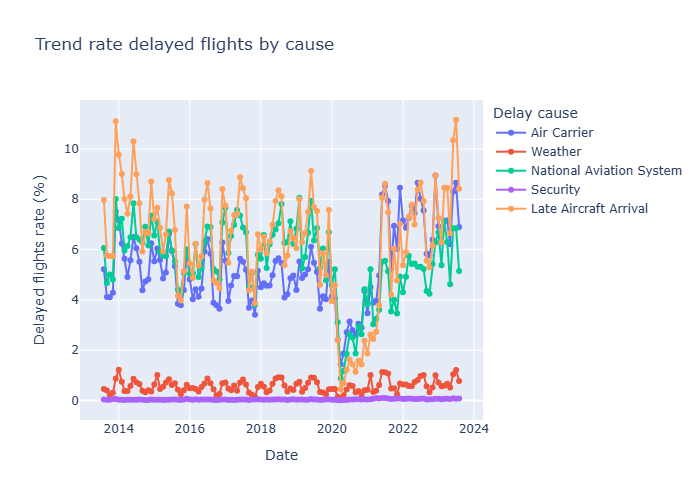

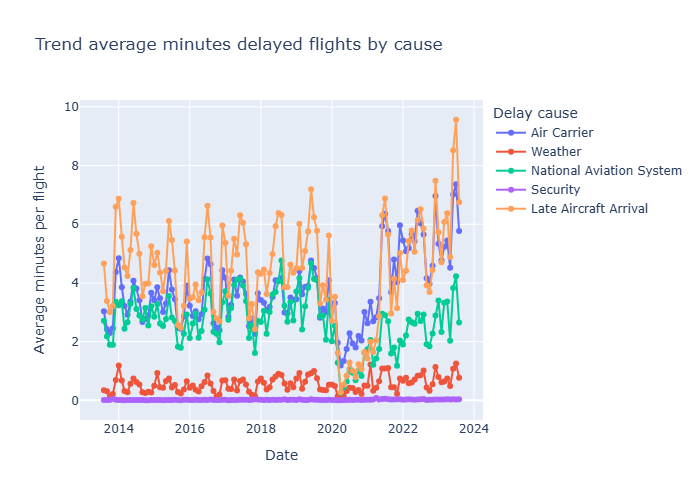

In [67]:
# create a line chart to visualize the number of delayed flights per year 
fig = px.line(df_trend_count_plot, x='date', y='Delayed flights rate (%)', color='Delay cause', markers = True, title='Trend rate delayed flights by cause')
fig.update_layout(xaxis_title='Date')
fig.show()

# create a line chart to visualize the minutes of delayed flights per year 
fig = px.line(df_trend_minutes_plot, x='date', y='Average minutes per flight', color='Delay cause', markers = True, title='Trend average minutes delayed flights by cause')
fig.update_layout(xaxis_title='Date')
fig.show()

The graphs show a seasonal pattern, which will be explored in more detail later, and that there was a sharp drop in delays between early 2020 and mid-2021. This is likely due to a sharp fall in the number of flights caused by the COVID-19 pandemic. With regard to our research, it is evident that the main causes of flight delays are attributable to the airline and to the aircraft arriving late.

In [68]:
# modify the df structure to have a column for each delay cause, with the count of delayed flights for each cause, grouped by year and month

# aggregate the causes by year and month, summing the counts for each cause
all_cols = list(cause_count_cols.keys()) + list(cause_delay_cols.keys()) + ["arr_flights"]
df_agg_cause = df_top.groupby(["month"])[all_cols].sum().reset_index()

# create a date column from the year and month
df_agg_cause = df_agg_cause.sort_values("month")
df_agg_cause["month_name"] = df_agg_cause["month"].apply(lambda m: calendar.month_abbr[m])

# Calculate the percentage of delayed flights for each cause (count of delayed flights / total flights * 100)
for col, name in cause_count_cols.items():
    df_agg_cause[f"{name}_rate"] = (df_agg_cause[col] / df_agg_cause["arr_flights"]) * 100

# Calculate the average delay in minutes for each cause (total delay minutes / total flights)
for col, name in cause_delay_cols.items():
    df_agg_cause[f"{name}_min"] = (df_agg_cause[col] / df_agg_cause["arr_flights"])

# Melt count of delayed flights
df_trend_month_count_plot = df_agg_cause.melt(
    id_vars=["month", "month_name"],
    value_vars=list(f"{name}_rate" for name in cause_count_cols.values()),
    var_name="Delay cause",
    value_name="Delayed flights rate (%)",
)
# Map the delay cause columns to clear labels
df_trend_month_count_plot["Delay cause"] = df_trend_month_count_plot["Delay cause"].str.replace("_rate", "")

# Melt minutes of delay
df_trend_month_minutes_plot = df_agg_cause.melt(
    id_vars=["month", "month_name"],
    value_vars=list(f"{name}_min" for name in cause_delay_cols.values()),
    var_name="Delay cause",
    value_name="Average minutes per flight",
)
# Map the delay minutes cause columns to clear labels
df_trend_month_minutes_plot["Delay cause"] = df_trend_month_minutes_plot["Delay cause"].str.replace("_min", "")

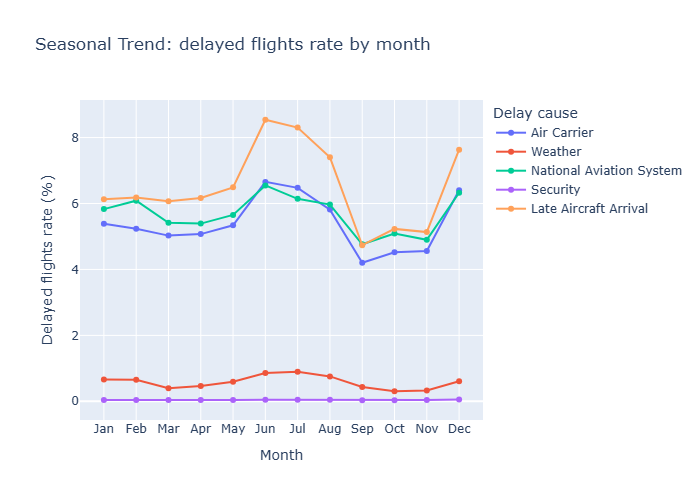

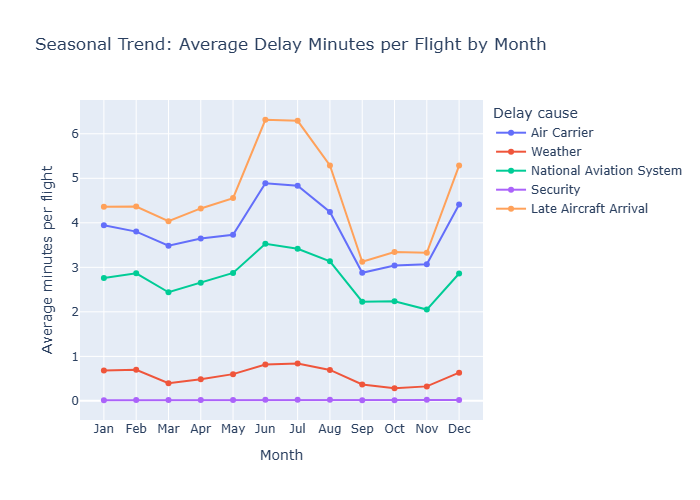

In [69]:
# Count of delayed flights per month
fig_count = px.line(df_trend_month_count_plot, x="month_name", y="Delayed flights rate (%)", color="Delay cause", markers=True, title="Seasonal Trend: delayed flights rate by month")
fig_count.update_layout(xaxis_title='Month')
fig_count.show()

# Minutes of delay per month
fig_minutes = px.line(df_trend_month_minutes_plot, x="month_name", y="Average minutes per flight", color="Delay cause", markers=True, title="Seasonal Trend: Average Delay Minutes per Flight by Month")
fig_minutes.update_layout(xaxis_title='Month')
fig_minutes.show()

In June, July, August and December, there is an increase in delays, probably due to a rise in the number of flights.

## Bar chart

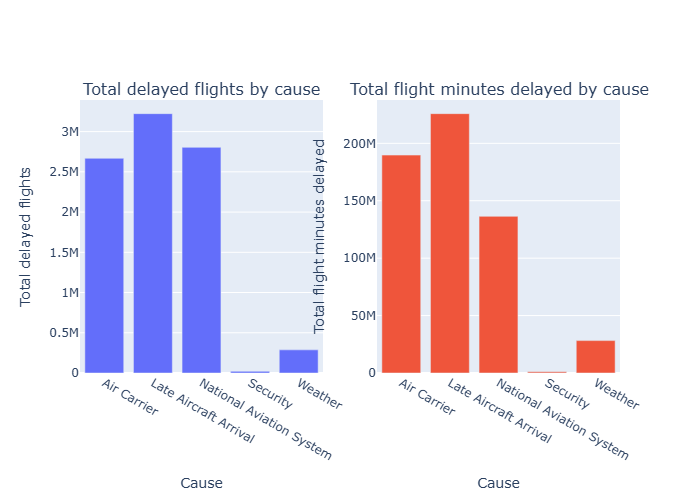

In [70]:
# create a dataframe with the casues and the total number of delayed flights for each cause, sorted by the total number of delayed flights
data_cause_count = (
    df_top[cause_count_cols.keys()].sum()
    .rename(cause_count_cols)
    .rename_axis("Cause")
    .reset_index(name="Total flights delayed")
    .sort_values("Cause", ascending=True)
)

# create a dataframe with the casues and the total number of delayed minutes for each cause, sorted by the total number of delayed minutes
data_cause_minutes = (
    df_top[cause_delay_cols.keys()].sum()
    .rename(cause_delay_cols)
    .rename_axis("Cause")
    .reset_index(name="Total flights minutes delayed")
    .sort_values("Cause", ascending=True)
)

# grid creation for the two bar charts
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Total delayed flights by cause",
        "Total flight minutes delayed by cause",
    ),
)

# first graph: Count of delayed flights
fig.add_trace(
    go.Bar(
        x=data_cause_count["Cause"],
        y=data_cause_count["Total flights delayed"],
    ),
    row=1,
    col=1,
)
fig.update_xaxes(title_text="Cause", row=1, col=1)
fig.update_yaxes(title_text="Total delayed flights", row=1, col=1)

# second graph: Minutes of delayed flights
fig.add_trace(
    go.Bar(
        x=data_cause_minutes["Cause"],
        y=data_cause_minutes["Total flights minutes delayed"],
    ),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Cause", row=1, col=2)
fig.update_yaxes(title_text="Total flight minutes delayed", row=1, col=2)

# remove the legend from the figure
fig.update_layout(showlegend=False)

fig.show()

We can clearly see that late aircraft are the main cause of delays, alongside airlines and the national airspace system. However, it is worth noting that the national airspace system, despite affecting more flights than airlines, accounts for fewer minutes of delay. 

## Boxplot

In [71]:
# add columns delay per flight 
df_top_delay_per_flight = df_top.copy()
for c in ["carrier", "weather", "nas", "security", "late_aircraft"]:
    df_top_delay_per_flight[f"{c}_delay_per_flight"] = df_top_delay_per_flight[f"{c}_delay"] / df_top_delay_per_flight[f"{c}_ct"]

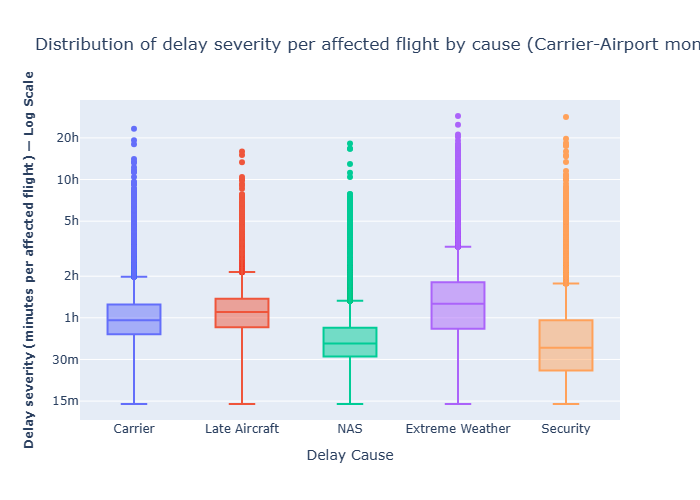

In [72]:
# Map the delay cause columns to clear labels
cause_cols = {
    "carrier_delay_per_flight": "Carrier",
    "late_aircraft_delay_per_flight": "Late Aircraft",
    "nas_delay_per_flight": "NAS",
    "weather_delay_per_flight": "Extreme Weather",
    "security_delay_per_flight": "Security"
}
    
# Reshape da wide a long, in order to have a column for the delay cause and a column for the delay per flight
df_long = df_top_delay_per_flight.melt(
    value_vars=list(cause_cols.keys()),
    var_name="cause_key",
    value_name="delay_per_flight"
)

# Clean the data: replace inf with NaN and drop rows with NaN values in the delay_per_flight column
df_long["delay_per_flight"] = df_long["delay_per_flight"].replace([np.inf, -np.inf], np.nan)
df_long = df_long.dropna(subset=["delay_per_flight"])
df_long = df_long[df_long["delay_per_flight"] > 0] # only positive value

# Rename the delay cause column to have clear labels
df_long["Delay Cause"] = df_long["cause_key"].map(cause_cols)

# Boxplot 
fig = px.box(
    df_long,
    x="Delay Cause",
    y="delay_per_flight",
    color="Delay Cause",
    title="Distribution of delay severity per affected flight by cause (Carrier-Airport monthly observations, 2013–2023)"
)

fig.update_layout(
    yaxis=dict(
        type="log",
        title="<b>Delay severity (minutes per affected flight) — Log Scale</b>",
        title_font=dict(size=12),
        # Define explicit ticks that are easily interpretable
        tickvals=[15, 30, 60, 120, 300, 600, 1200],
        ticktext=["15m", "30m", "1h", "2h", "5h", "10h", "20h"],
        showgrid=True,
    ),
    showlegend=False
)

fig.show()

The impact of weather events is severe, with average delays exceeding an hour and a half. Other causes, such as NAS and security issues, have a more limited and ongoing impact.

## Correlation heatmap

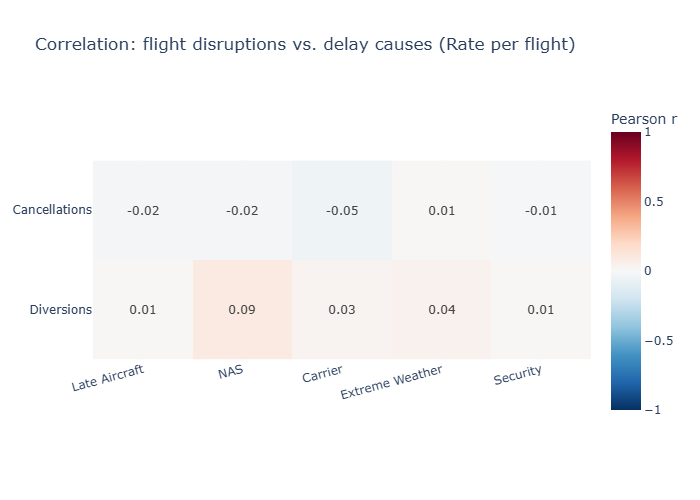

In [73]:
# eliminating very small samples that could distort rate ratios
# df_corr = df_top[df_top["arr_flights"] >= 50].copy()
df_corr = df_top.copy()

# derive normalized rates per arriving flight, ct / arr_flights
metrics = {
    "Cancellations": df_corr["arr_cancelled"] / df_corr["arr_flights"],
    "Diversions": df_corr["arr_diverted"] / df_corr["arr_flights"],
    "Late Aircraft": df_corr["late_aircraft_ct"] / df_corr["arr_flights"],
    "NAS": df_corr["nas_ct"] / df_corr["arr_flights"],
    "Carrier": df_corr["carrier_ct"] / df_corr["arr_flights"],
    "Extreme Weather": df_corr["weather_ct"] / df_corr["arr_flights"],
    "Security": df_corr["security_ct"] / df_corr["arr_flights"],
}

df_rates = pd.DataFrame(metrics)

# Pearson correlation matrix
corr_matrix = df_rates.corr(method="pearson").round(2)

# Focus specifically on disruptions (rows) vs. the 5 delay causes (columns)
row_labels = ["Cancellations", "Diversions"]
col_labels = ["Late Aircraft", "NAS", "Carrier", "Extreme Weather", "Security"]

sub_corr = corr_matrix.loc[row_labels, col_labels]

# Heatmap with diverging color palette
fig = px.imshow(
    sub_corr,
    labels=dict(
        x="Delay Cause (Rate per Flight)",
        y="Disruption Type",
        color="Pearson r",
    ),
    x=col_labels,
    y=row_labels,
    color_continuous_scale="RdBu_r",  # blue = negative, white = 0, red = positive
    range_color=[-1, 1],
    text_auto=".2f",
    title="Correlation: flight disruptions vs. delay causes (Rate per flight)"
)

fig.update_layout(
    template="plotly_white",
    xaxis=dict(title=None, tickangle=-15),
    yaxis=dict(title=None),
)

fig.show()

All correlations are close to zero (between -0.05 and 0.09), showing no meaningful linear relationship between delay causes and either cancellations or diversions.

## Stacked bar chart

In [74]:
# define the lists
delay_ct_causes = [
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
]

delay_minutes_causes = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
]

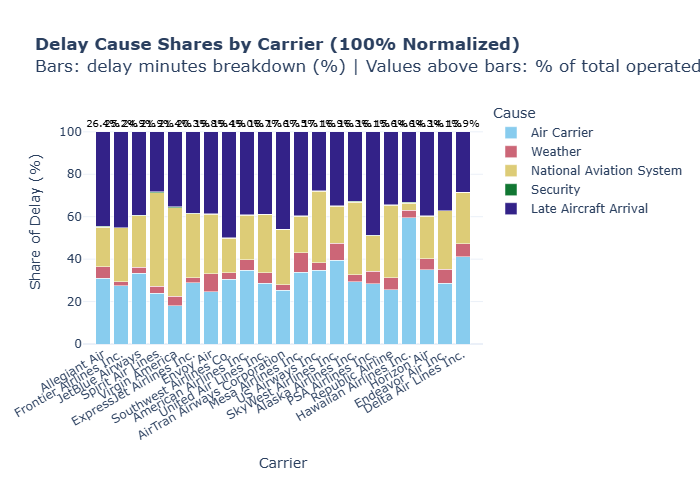

In [75]:
# groupby for each carrier and sum the delay minutes for each cause
df_carrier_minutes = df_top.groupby("carrier_name")[delay_minutes_causes].sum()

# horizontal sum of total minutes for each carrier (axis=1), then divide each cause by the total minutes to get the share of each cause for each carrier
df_carrier_share = df_carrier_minutes.div(df_carrier_minutes.sum(axis=1), axis=0) * 100
# reset the index to have a column for the carrier name
df_carrier_share = df_carrier_share.reset_index()

# reshape the dataframe to have a column for the carrier name, a column for the cause, and a column for the share of delay minutes for each cause
df_carrier_long = df_carrier_share.melt(
    id_vars="carrier_name",
    value_vars=delay_minutes_causes,
    var_name="cause",
    value_name="share_pct",
)
# Map the delay cause columns to clear labels
df_carrier_long["cause"] = df_carrier_long["cause"].map(cause_delay_cols)

# Calculate the delay percentage for each carrier
carrier_rates = (df_top.groupby("carrier_name").agg(tot_flights=("arr_flights", "sum"), del_flights=("arr_del15", "sum")).reset_index())
carrier_rates["del_pct"] = (carrier_rates["del_flights"] / carrier_rates["tot_flights"] * 100).round(1)

# sort carrier from highest to lowest delay rate for visualization purposes
ordered_carriers = carrier_rates.sort_values("del_pct", ascending=False)["carrier_name"].tolist()

# Visualisation
fig_carrier = px.bar(
    df_carrier_long,
    x="carrier_name",
    y="share_pct",
    color="cause",
    category_orders={"carrier_name": ordered_carriers},
    title=(
        "<b>Delay Cause Shares by Carrier (100% Normalized)</b><br>"
        "Bars: delay minutes breakdown (%) | Values above bars: % of total operated flights delayed (≥15 min)"
        "</span>"
        ),
    labels={
        "carrier_name": "Carrier",
        "share_pct": "Share of Delay (%)",
        "cause": "Cause",
    },
    # safe colors for better visibility and accessibility
    color_discrete_sequence=px.colors.qualitative.Safe,
)

# Add text annotations for the delay percentage above each carrier's bar
fig_carrier.add_trace(
    go.Scatter(
        x=carrier_rates["carrier_name"],
        y=[101] * len(carrier_rates),
        mode="text",
        text=carrier_rates["del_pct"].apply(lambda val: f"{val:.1f}%"),
        textposition="top center",
        textfont=dict(size=10, color="black"),
        showlegend=False,
        hoverinfo="skip",
    )
)

# Update layout to stack bars and adjust y-axis range and ticks
fig_carrier.update_layout(
    barmode="stack",
    yaxis=dict(
        ticksuffix="%",
        range=[0, 115],
        tickvals=[0, 20, 40, 60, 80, 100], 
    ),
    xaxis=dict(tickangle=-30),
    template="plotly_white",
    height=480,
)

fig_carrier.show()

Flight delays exhibit a consistent pattern of causes amongst continental carriers, dominated by the domino effect of late aircraft arrivals (35–50 per cent) and infrastructure congestion within the NAS (20–30 per cent), whilst weather and security have a negligible impact (<5 per cent). The only real exception is Hawaiian Airlines, where the absence of complex flight rotations eliminates knock-on delays and means that 60 per cent of disruptions are attributable to the carrier’s internal operations (Air Carrier).

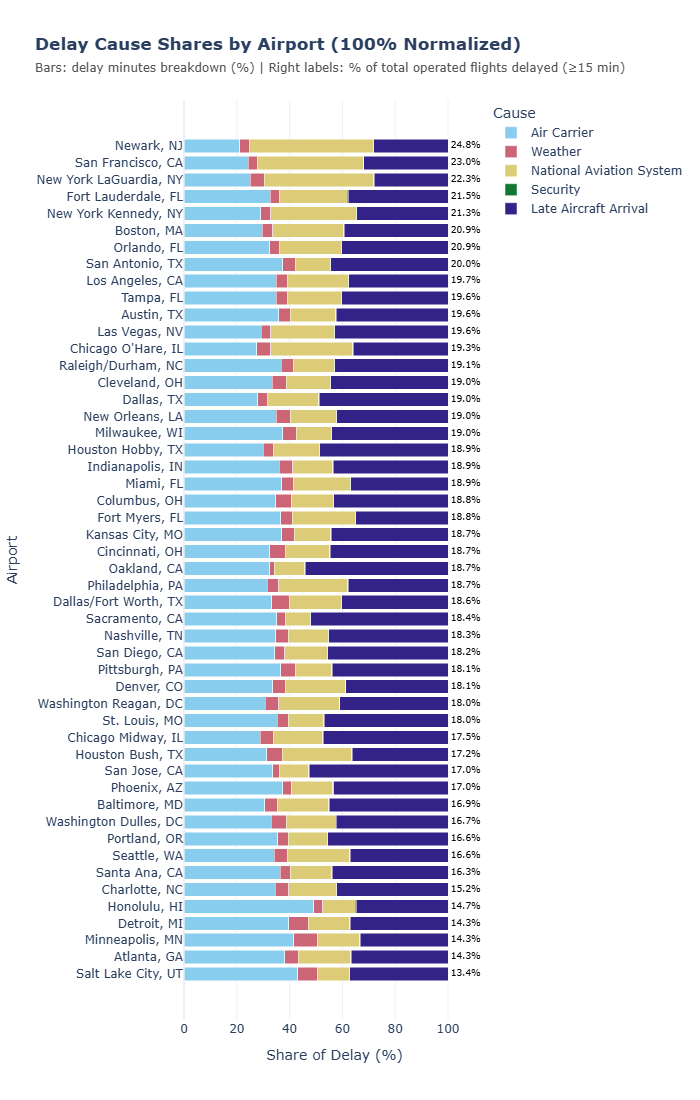

In [76]:
# sum delay minutes per cause and normalize shares to 100% across all airports
df_airport_minutes = df_top.groupby("airport_name")[delay_minutes_causes].sum()
df_airport_share = (df_airport_minutes.div(df_airport_minutes.sum(axis=1), axis=0) * 100).reset_index()

# reshape dataframe to long format
df_airport_long = df_airport_share.melt(
    id_vars="airport_name",
    value_vars=delay_minutes_causes,
    var_name="cause",
    value_name="share_pct",
)
df_airport_long["cause"] = df_airport_long["cause"].map(cause_delay_cols)

# compute overall delay rate per airport
airport_rates = (
    df_top.groupby("airport_name")
    .agg(tot_flights=("arr_flights", "sum"), del_flights=("arr_del15", "sum"))
    .reset_index()
)
airport_rates["del_pct"] = (airport_rates["del_flights"] / airport_rates["tot_flights"] * 100).round(1)

# sort airports from lowest to highest delay rate
ordered_airports = airport_rates.sort_values("del_pct", ascending=True)["airport_name"].tolist()

# horizontal stacked bar visualization
fig_airport_h = px.bar(
    df_airport_long,
    x="share_pct",
    y="airport_name",
    color="cause",
    orientation="h",
    category_orders={"airport_name": ordered_airports},
    title=(
        "<b>Delay Cause Shares by Airport (100% Normalized)</b><br>"
        "<span style='font-size: 12px; color: #555555; font-weight: normal;'>"
        "Bars: delay minutes breakdown (%) | Right labels: % of total operated flights delayed (≥15 min)"
        "</span>"
    ),
    labels={
        "airport_name": "Airport",
        "share_pct": "Share of Delay (%)",
        "cause": "Cause",
    },
    color_discrete_sequence=px.colors.qualitative.Safe,
)

# place numerical annotations directly to the right of each bar (x=101%)
fig_airport_h.add_trace(
    go.Scatter(
        x=[101] * len(airport_rates),
        y=airport_rates["airport_name"],
        mode="text",
        text=airport_rates["del_pct"].apply(lambda val: f"{val:.1f}%"),
        textposition="middle right",
        textfont=dict(size=9, color='black'),
        showlegend=False,
        hoverinfo="skip",
    )
)

# dynamic figure height to accommodate all categories comfortably
num_airports = len(df_airport_share)
plot_height = max(500, num_airports * 22)

fig_airport_h.update_layout(
    barmode="stack",
    xaxis=dict(
        ticksuffix="%",
        range=[0, 114],
        tickvals=[0, 20, 40, 60, 80, 100],
    ),
    yaxis=dict(autorange="reversed"),  
    template="plotly_white",
    height=plot_height,
    margin=dict(r=60),  
)

fig_airport_h.show()

The chart clearly shows that the most problematic airports (with over 22 per cent of flights delayed) suffer primarily from heavy air traffic and congested runways (NAS, the yellow band). At the best-run and most organised airports, such as Atlanta or Minneapolis (where delays stand at 14 per cent), traffic flows more smoothly and most delays are simply due to aircraft arriving late from their previous flight. The exception is Honolulu in Hawaii: as it is an island off the mainland routes, it does not suffer from the knock-on effect seen at other airports, and almost all delays are down solely to the airlines’ internal management.

## Scatter plot

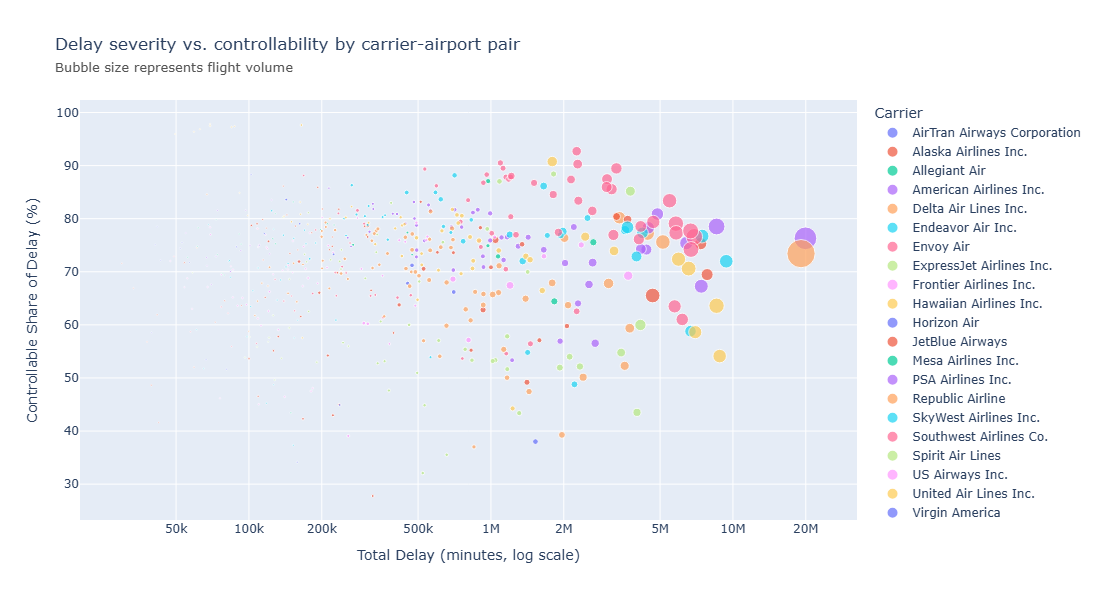

In [77]:
# function for building the scatter data based on selected year range, airports, and carriers (usable for Dashboard)
def build_scatter_data(year_range, selected_airports, selected_carriers):
    # sum over the selected years for each carrier-airport pair
    dff = df_top[
            df_top["airport_name"].isin(selected_airports)
            & df_top["carrier_name"].isin(selected_carriers)
            & df_top["year"].between(year_range[0], year_range[1])
        ]
    
    agg = dff.groupby(["carrier_name", "airport_name"], as_index=False).agg(
        arr_delay=("arr_delay", "sum"),
        carrier_delay=("carrier_delay", "sum"),
        late_aircraft_delay=("late_aircraft_delay", "sum"),
        arr_flights=("arr_flights", "sum"),
    )

    # calculate the controllable share of delay
    agg["controllable_share"] = (agg["carrier_delay"] + agg["late_aircraft_delay"]) / agg["arr_delay"] * 100

    # filter small couples
    agg = agg[(agg["arr_flights"] >= 5000) & (agg["arr_delay"] > 0)].copy()
    return agg

# function for building the scatter figure based on selected year range, airports, and carriers (usable for Dashboard)
def build_scatter_figure(year_range, selected_airports, selected_carriers):
    agg = build_scatter_data(year_range, selected_airports, selected_carriers)
    fig = px.scatter(
        agg, x="arr_delay", y="controllable_share",
        color="carrier_name", size="arr_flights",
        hover_data=["airport_name"],
        custom_data=["airport_name", "carrier_name"],
        log_x=True, 
        title=("</b>Delay severity vs. controllability by carrier-airport pair</b><br>"
               "<span style='font-size: 13px; color: #555; font-weight: normal;'>"
                "Bubble size represents flight volume")
    )
    
    return fig

#### DEFAULT VIEW: full year, carrier, and airport range available

# full year range available
FULL_YEAR_RANGE = (int(df_top["year"].min()), int(df_top["year"].max()))

airports = (
    df_top["airport_name"]
    .drop_duplicates()
    .tolist()
)

carriers = (
    df_top["carrier_name"]
    .drop_duplicates()
    .tolist()
)

fig_scatter = build_scatter_figure(FULL_YEAR_RANGE, airports, carriers)

fig_scatter.update_layout(
        xaxis=dict(
            title="Total Delay (minutes, log scale)",
            # for better readability, define explicit ticks that are easily interpretable
            tickmode="array",
            tickvals=[50000, 100000, 200000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000],
            ticktext=["50k", "100k", "200k", "500k", "1M", "2M", "5M", "10M", "20M"],
            showgrid=True,
        ),
        yaxis=dict(title="Controllable Share of Delay (%)"),
        legend_title_text='Carrier',
        height=600,
        width=1100
    )

fig_scatter.show()

The scatter plot shows that as the number of accumulated minutes of delay increases (moving to the right), the data points do not fall but remain firmly concentrated within the range between 70 per cent and 85 per cent of the controllable share. This demonstrates that major network disruptions are not caused by uncontrollable external factors (such as weather or air traffic), but rather by internal operational inefficiencies within the airlines, primarily the knock-on effect of delays from one flight to the next (Late Aircraft). The two large clusters on the far right confirm that the saturation of mega-hubs systematically exacerbates this operational issue.

## Symbol map

In [78]:
airport_agg = (df_top.groupby(["airport", "airport_name", "latitude_deg", "longitude_deg"], as_index=False)
                 .agg(arr_flights=("arr_flights", "sum"),arr_del15=("arr_del15", "sum")))

airport_agg["pct_delayed"] = (airport_agg["arr_del15"] / airport_agg["arr_flights"]) * 100

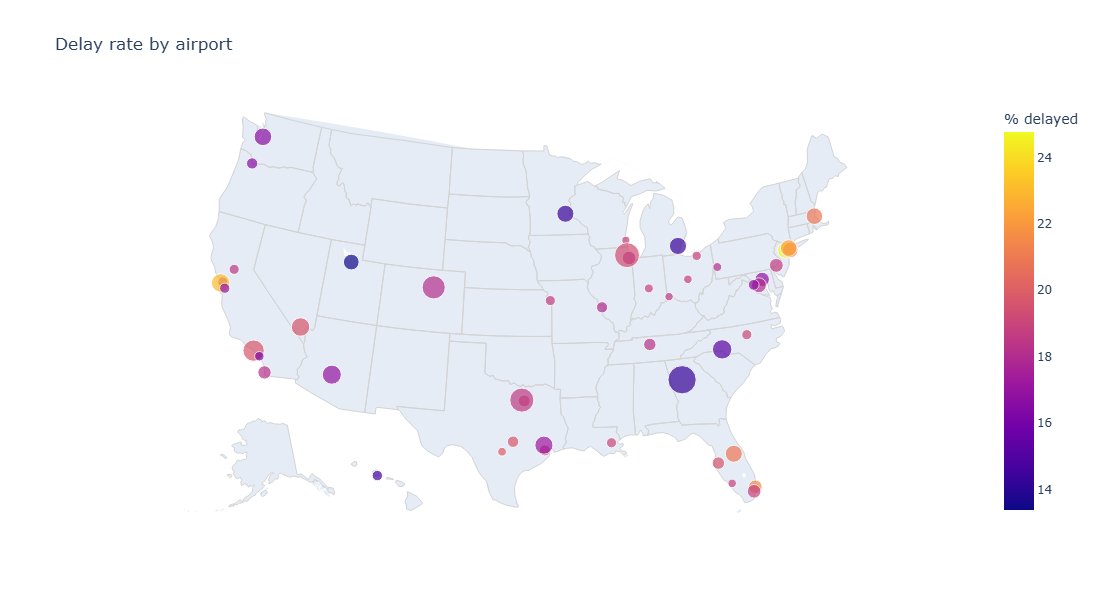

In [79]:
fig = px.scatter_geo(
    airport_agg,
    lat="latitude_deg", lon="longitude_deg",
    size="arr_flights",
    color="pct_delayed",
    hover_name="airport_name",
    scope="usa",
    color_continuous_scale="Plasma",
    labels={"pct_delayed": "% delayed", "arr_flights": "Arrivals"},
    title="Delay rate by airport"
)
fig.update_layout(height=600, width=1100)

fig.update_geos(showsubunits=True, subunitcolor="lightgray")
fig.show()

The map clearly shows that a higher flight volume does not necessarily lead to worse delays. In fact, the largest hub in the network, Atlanta, achieves one of the lowest delay rates nationwide at around 14% (dark green), proving that high capacity can coexist with operational efficiency. Instead, severe delays (above 22–24%, shown in red) are concentrated in specific geographic bottlenecks, most notably the crowded New York metropolitan airspace and San Francisco.

## Treemap

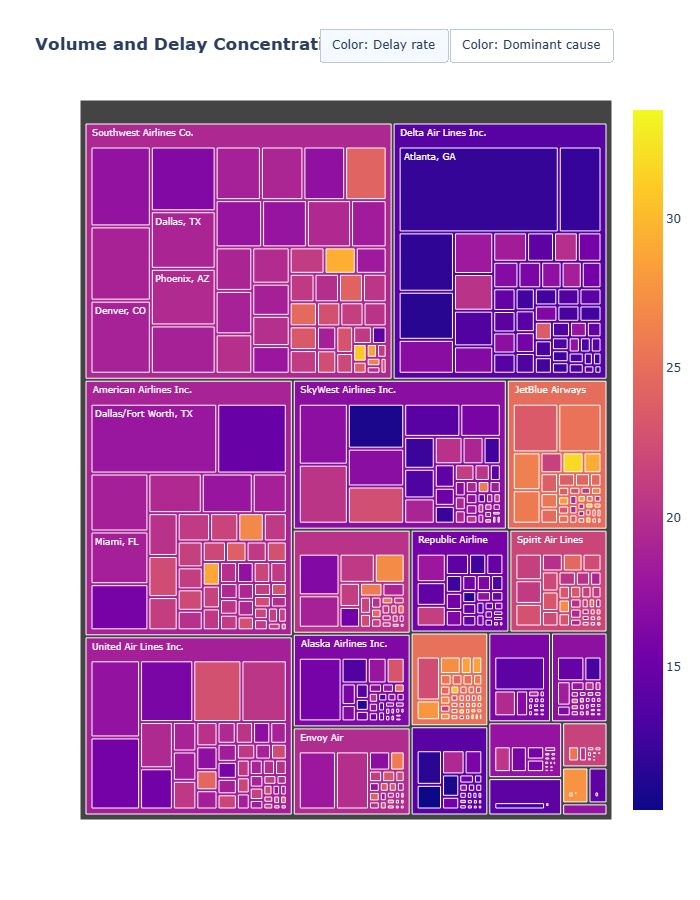

In [80]:
# Aggregate arr_flights, arr_del15 and each cause count by carrier and airport
treemap_agg = df_top.groupby(["carrier_name", "airport_name"], as_index=False).agg(
    arr_flights=("arr_flights", "sum"),
    arr_del15=("arr_del15", "sum"),
    carrier_ct=("carrier_ct", "sum"),
    weather_ct=("weather_ct", "sum"),
    nas_ct=("nas_ct", "sum"),
    security_ct=("security_ct", "sum"),
    late_aircraft_ct=("late_aircraft_ct", "sum"),
)

# drop very small carrier-airport pairs, they'd only clutter the treemap with tiny boxes
treemap_agg = treemap_agg[treemap_agg["arr_flights"] >= 5000].copy()

# delay rate (% of flights delayed 15+ minutes) for each carrier-airport pair
treemap_agg["pct_delayed"] = (treemap_agg["arr_del15"] / treemap_agg["arr_flights"]) * 100

# dominant delay cause: the one with the highest count of delayed flights for that pair
cause_ct_cols = list(cause_count_cols.keys())
treemap_agg["dominant_cause"] = treemap_agg[cause_ct_cols].idxmax(axis=1).map(cause_count_cols)

# for the hover
custom_cols = ["arr_flights", "pct_delayed", "dominant_cause"]

#  Treemap colored by delay rate (severity) 
fig_rate = px.treemap(
    treemap_agg,
    path=["carrier_name", "airport_name"],
    values="arr_flights",
    color="pct_delayed",
    color_discrete_sequence=px.colors.qualitative.Safe,
    custom_data=custom_cols
)

#  Treemap colored by dominant delay cause 
fig_cause = px.treemap(
    treemap_agg,
    path=["carrier_name", "airport_name"],
    values="arr_flights",
    color="dominant_cause",
    color_discrete_sequence=px.colors.qualitative.Safe,
    custom_data=custom_cols
)


# combine both colorings in one figure, toggled with buttons 
fig = go.Figure(data=[fig_rate.data[0], fig_cause.data[0]])
fig.data[1].visible = False

fig.update_layout(
    title="<b>Volume and Delay Concentration by Carrier and Airport</b>",
    height=900,
    uniformtext=dict(minsize=9, mode="hide"),  # hide text if it doesn't fit
    # buttons to toggle between the two colorings
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=1, xanchor="right",
            y=1.1, yanchor="top",
            buttons=[
                dict(
                    label="Color: Delay rate",
                    method="update",
                    args=[{"visible": [True, False]}, {"coloraxis.showscale": True}],
                ),
                dict(
                    label="Color: Dominant cause",
                    method="update",
                    args=[{"visible": [False, True]}, {"coloraxis.showscale": False}],
                ),
            ],
        )
    ],
)

# limit the depth of the treemap to 2 levels (carrier and airport) to avoid cluttering with too many small boxes
fig.update_traces(
    maxdepth=2, selector=dict(type="treemap"),
    hovertemplate=(
        "<b>%{label}</b> (%{parent})<br>"
        "Operated Flights: %{customdata[0]:,}<br>"
        "Delayed Flights: %{customdata[1]:.1f}%<br>"
        "Dominant Cause: %{customdata[2]}"
        "<extra></extra>"
    )
)

fig.show()

# Dashboard

In [81]:
CT_COLS = list(cause_count_cols.keys())
DELAY_COLS = list(cause_delay_cols.keys())

# lists for menu
airport_options = (
    df_top["airport_name"]
    .drop_duplicates()
    .sort_values()
    .apply(lambda r: {"label": r, "value": r})
    .tolist()
)
carrier_options = (
    df_top["carrier_name"]
    .drop_duplicates()
    .sort_values()
    .apply(lambda r: {"label": r, "value": r})
    .tolist()
)
 
YEAR_MIN, YEAR_MAX = int(df_top["year"].min()), int(df_top["year"].max())

In [82]:
################## LAYOUT APP
app = Dash(__name__)

# NOTE: H is for heading, Div is for division, and dcc is for dash core components (like graphs, sliders, etc.)
app.layout = html.Div(
    [
        html.H2("Flight Delay Analysis (2013–2023)", style={"margin": "0 0 8px 0", "fontSize": "20px"}),
        
        # Common filters container
        html.Div(
            [
                html.Div(
                    [
                        html.Label("Airports"),
                        dcc.Dropdown(
                            id="airport-selector",
                            options=airport_options,
                            multi=True,
                            value=[opt["value"] for opt in airport_options[:]],
                        ),
                    ],
                    style={"flex": "1"},
                ),
                html.Div(
                    [
                        html.Label("Carriers"),
                        dcc.Dropdown(
                            id="carrier-selector",
                            options=carrier_options,
                            multi=True,
                            value=[opt["value"] for opt in carrier_options[:]],
                        ),
                    ],
                    style={"flex": "1"},
                ),
                html.Div(
                    [
                        html.Label("Year Range"),
                        dcc.RangeSlider(
                            id="year-range-slider",
                            min=YEAR_MIN,
                            max=YEAR_MAX,
                            step=1,
                            value=[YEAR_MIN, YEAR_MAX],
                            marks={
                                y: {"label": str(y), "style": {"fontSize": "11px"}}
                                for y in range(YEAR_MIN, YEAR_MAX + 1)
                            },
                        ),
                    ],
                    style={"flex": "1.5", "paddingTop": "2px"},
                ),
            ],
            style={
                "display": "flex",          
                "flexDirection": "row",      
                "alignItems": "flex-start",  
                "gap": "20px",               
                "padding": "10px 5px",
                "width": "100%",
                "boxSizing": "border-box",
                "fontSize": "12px",
                "flex": "0 0 auto"
            },
        ),
    
        html.Div(
            [
                # Line Chart 
                html.Div(
                    dcc.Graph(
                        id="line-chart-causes",
                        style={"height": "100%", "width": "100%"},
                        config={"responsive": True},
                    ),
                    style={"flex": "1", "minWidth": "0", "maxWidth": "1100px", "height": "100%"},
                ),
                
                # Controls for view and metrics
                html.Div(
                    [
                        html.Div(
                            [
                                html.Label("View (line plot)", style={"fontWeight": "bold", "marginBottom": "6px", "display": "block"}),
                                dcc.RadioItems(
                                    id="view-mode",
                                    options=[
                                        {"label": "Trend in time", "value": "trend"},
                                        {"label": "Seasonality (per month)", "value": "seasonal"},
                                    ],
                                    value="trend",
                                    labelStyle={"display": "block", "marginBottom": "6px"},  
                                ),
                            ],
                            style={"marginBottom": "20px"},
                        ),
                        html.Div(
                            [
                                html.Label("Metrics (line plot and bar plot)", style={"fontWeight": "bold", "marginBottom": "6px", "display": "block"}),
                                dcc.RadioItems(
                                    id="metric-selector",
                                    options=[
                                        {"label": "Count flights", "value": "count"},
                                        {"label": "Minutes", "value": "minutes"},
                                    ],
                                    value="count",
                                    labelStyle={"display": "block", "marginBottom": "6px"},  
                                ),
                            ],
                        ),
                    ],
                    style={
                        "width": "200px",  
                        "flexShrink": "0",        
                        "padding": "15px 0px 0px 5px",
                        "fontSize": "12px",
                    },
                ),
            ],
            style={
                "display": "flex",
                "alignItems": "flex-start",
                "justifyContent": "flex-start",
                "width": "100%",
                "marginBottom": "20px",
                "overflow": "hidden",
                "flex": "0.9 1 0%",
                "minHeight": "0",
            },
        ),

        # Panel 2 and 3 
        html.Div(
            [
                # Bar Chart
                html.Div(
                    dcc.Graph(
                        id="bar-chart-causes",
                        style={"height": "100%", "width": "100%"},
                        config={"responsive": True},
                    ),
                    style={"flex": "0.65", "minWidth": "0", "height": "100%"},
                ),
                
                # Scatter Plot
                html.Div(
                    dcc.Graph(
                        id="scatter-delay-controllable",
                        style={"height": "100%", "width": "100%"},
                        config={"responsive": True},
                    ),
                    style={"flex": "1", "minWidth": "0", "height": "100%", "width": "80%"},
                ),
            ],
            style={
                "display": "flex",
                "flexDirection": "row",
                "alignItems": "stretch",
                "justifyContent": "space-between",
                "gap": "20px",
                "width": "100%",
                "flex": "0.90 0.85 0%",
                "minHeight": "0",
                "marginBottom": "10px",
                "paddingRight": "15px",  # Evita che la legenda dello scatter tocchi il bordo destro
                "boxSizing": "border-box",
            },
        ),
    ],
    style={
        "height": "100vh",
        "display": "flex",
        "flexDirection": "column",
        "flex": "0 0 40%",
        "padding": "12px",
        "boxSizing": "border-box",
        "overflow": "hidden",   # no scroll
        "backgroundColor":"#ffffff",
        "fontFamily": "Arial, sans-serif",
    },
)

################## LINE CHART CALLBACK

# This callback updates the line chart based on the selected filters
@app.callback(
    Output("line-chart-causes", "figure"),
    Input("airport-selector", "value"),
    Input("carrier-selector", "value"),
    Input("year-range-slider", "value"),
    Input("view-mode", "value"),
    Input("metric-selector", "value"),
)

def update_line_chart(selected_airports, selected_carriers, year_range, view_mode, metric):
    if not selected_airports or not selected_carriers:
        return go.Figure()
 
    dff = df_top[
        df_top["airport_name"].isin(selected_airports)
        & df_top["carrier_name"].isin(selected_carriers)
        & df_top["year"].between(year_range[0], year_range[1])
    ]
 
    all_cols = CT_COLS + DELAY_COLS + ["arr_flights"]
 
    if view_mode == "trend":
        # Trend in time: a point for each month of each year, summing over all selected airports and carriers
        group_cols = ["year", "month"]
    else:
        # Seasonality: a point for each month, summing over all selected airports and carriers and all years
        group_cols = ["month"]
 
    agg = dff.groupby(group_cols)[all_cols].sum().reset_index()
    
    # Calculate the percentage of delayed flights for each cause (count of delayed flights / total flights * 100)
    for col, label in cause_count_cols.items():
        agg[f"{label}_rate"] = (agg[col] / agg["arr_flights"]) * 100
 
    # Average delay in minutes per flight, per cause (minutes cause / total flights)
    for col, label in cause_delay_cols.items():
        agg[f"{label}_min"] = agg[col] / agg["arr_flights"]
    
    # Determine which columns to use for the y-axis based on the selected metric
    if metric == "count":
        value_vars = [f"{label}_rate" for label in cause_count_cols.values()]
        suffix, y_label = "_rate", "Delay rate (%) delayed flights/total flights"
    else:
        value_vars = [f"{label}_min" for label in cause_delay_cols.values()]
        suffix, y_label = "_min", "Average delay (minutes)"
    
    # Prepare the data for plotting based on the selected view mode
    if view_mode == "trend":
        agg["date"] = pd.to_datetime(agg[["year", "month"]].assign(day=1))
        agg = agg.sort_values("date")
        id_vars, x_col = ["date", "year", "month"], "date"
    else:
        agg = agg.sort_values("month")
        agg["month_name"] = agg["month"].apply(lambda m: calendar.month_abbr[m])
        id_vars, x_col = ["month", "month_name"], "month_name"
 
    long_df = agg.melt(id_vars=id_vars, value_vars=value_vars, var_name="Delay cause", value_name=y_label)
    long_df["Delay cause"] = long_df["Delay cause"].str.replace(suffix, "", regex=False)
 
    title = "Trend of delay causes" if view_mode == "trend" else "Seasonality of delay causes (by month)"
    fig = px.line(long_df, x=x_col, y=y_label, color="Delay cause", markers=True, title=title)
    fig.update_layout(autosize=True, margin={"l": 40, "b": 10, "t": 60, "r": 0}, legend_title_text="Cause", height=340)
    return fig

################## BAR CHART CALLBACK

@app.callback(
    Output("bar-chart-causes", "figure"),
    Input("airport-selector", "value"),
    Input("carrier-selector", "value"),
    Input("year-range-slider", "value"),
    Input("metric-selector", "value"),
)
def update_bar_chart(selected_airports, selected_carriers, year_range, metric):
    if not selected_airports or not selected_carriers:
        return go.Figure()
 
    dff = df_top[
        df_top["airport_name"].isin(selected_airports)
        & df_top["carrier_name"].isin(selected_carriers)
        & df_top["year"].between(year_range[0], year_range[1])
    ]
 
    ct_sums = dff[CT_COLS].sum()
    delay_sums = dff[DELAY_COLS].sum()
    
    # Determine which columns to use for the y-axis based on the selected metric
    if metric == "count":
        y_sum = ct_sums
        name = "Delayed Flights Count"
    else:
        y_sum = delay_sums
        name = "Delay Minutes total"
 
    fig = go.Figure()
    fig.add_trace(go.Bar(x=list(cause_count_cols.values()), y=y_sum.values, name=name))
    
    fig.update_layout(
        title="Delay Causes: Total Delayed Flights and Delay Minutes",
        xaxis=dict(title="Delay Cause"),
        yaxis=dict(title=name),
        barmode="group",
        autosize=True,
        width=None,
        margin=dict(l=50, r=20, t=35, b=35),
    )
    return fig

################### SCATTER PLOT CALLBACK

@app.callback(
    Output("scatter-delay-controllable", "figure"),
    Input("airport-selector", "value"),  # solo per evidenziare i punti selezionati
    Input("carrier-selector", "value"),
    Input("year-range-slider", "value"),
)
def update_scatter(selected_airports, selected_carriers, year_range):
    if not selected_airports or not selected_carriers:
        return go.Figure()
 
    fig = build_scatter_figure(year_range, selected_airports, selected_carriers)
 
    fig.update_layout(
        legend_title_text="Carrier",
        yaxis=dict(title="Controllable Share of Delay (%)"),
        xaxis=dict(title="Total Delay (minutes, log scale)"),
        height=None,
        autosize=True,
        width=None,
        margin=dict(l=40, r=40, t=40, b=30),
    )
    return fig

##################### RUN APP
if __name__ == "__main__":
    app.run(debug=True, jupyter_mode='inline')


# Conclusions

General conclusions:

- Late Aircraft Arrival and Air Carrier issues account for the vast majority of network disruptions, showing that cascading delays and internal operations have a much bigger impact than weather conditions.

- High flight volume does not necessarily cause higher delay rates; massive hubs like Atlanta (ATL) maintain some of the best on-time performances in the country.

- The most severe delay rates are concentrated on the coasts in specific congested areas (especially the New York and the San Francisco), where physical airspace constraints (NAS) outweigh individual airline efficiency.

- While extreme weather causes the longest individual flight delays, most of the total delay minutes across the network come from cascading delays (Late Aircraft).

Examples:

- High Priority could be American at Dallas or Delta airlines at Atlanta: High cumulative delay volume but with $>75\%$ controllable share. Ideal candidates for internal operational budget (improving ground turnarounds and buffer schedules).

- Low Operational Priority (United airlines at Newark): Controllable share drops to $50\%$ due to heavy external airspace congestion (NAS). Internal airline investments here would have limited return since delays are driven by external infrastructure.

The FAA should focus its efforts on a few congested areas, while the main responsibility for punctuality lies with airlines, which must prioritize operational resilience over excessively tight turnaround schedules.